# CIFAR-10 Classification with ResNet18, EfficientNetB0

## 1. Setup
Reference: https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html

In [21]:
import os

SAVE_DIR = './cifar10_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Models will be saved to: {os.path.abspath(SAVE_DIR)}')

Models will be saved to: c:\Users\Uma Banik\OneDrive\Desktop\468 assignment\cifar10_models


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
from PIL import Image
import copy
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CLASSES    = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
NUM_CLASSES = 10
BATCH_SIZE  = 64
EPOCHS      = 20
LR          = 0.001

Using device: cuda


## 2. Dataset Loading
Reference: https://huggingface.co/datasets/uoft-cs/cifar10

In [23]:
raw = load_dataset('uoft-cs/cifar10')
print(raw)
print(f"Train samples: {len(raw['train'])}, Test samples: {len(raw['test'])}")

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})
Train samples: 50000, Test samples: 10000


## 3. Data Preprocessing
Reference: https://docs.pytorch.org/vision/0.21/transforms.html

In [24]:
CIFAR10_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR10_STD  = [0.2470, 0.2435, 0.2616]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=28),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])


class CIFAR10Dataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]['img']
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        img = img.convert('RGB')
        label = self.data[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label


full_train = CIFAR10Dataset(raw['train'], transform=None)
train_size = int(0.9 * len(full_train))
val_size   = len(full_train) - train_size
train_indices, val_indices = random_split(range(len(full_train)), [train_size, val_size])

train_dataset = CIFAR10Dataset(
    [raw['train'][i] for i in train_indices.indices], transform=train_transform)
val_dataset   = CIFAR10Dataset(
    [raw['train'][i] for i in val_indices.indices],   transform=val_test_transform)
test_dataset  = CIFAR10Dataset(raw['test'],            transform=val_test_transform)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 45000 | Val: 5000 | Test: 10000


In [25]:
CIFAR10_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR10_STD  = [0.2470, 0.2435, 0.2616]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=28),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])


class CIFAR10Dataset(Dataset):
    def __init__(self, hf_data, indices, transform=None):
        self.data      = hf_data
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img      = self.data[real_idx]['img']
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        img   = img.convert('RGB')
        label = self.data[real_idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label


total      = len(raw['train'])
train_size = int(0.9 * total)
all_idx    = list(range(total))
train_idx  = all_idx[:train_size]
val_idx    = all_idx[train_size:]

train_dataset = CIFAR10Dataset(raw['train'], train_idx, transform=train_transform)
val_dataset   = CIFAR10Dataset(raw['train'], val_idx,   transform=val_test_transform)
test_dataset  = CIFAR10Dataset(raw['test'],  list(range(len(raw['test']))), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 45000 | Val: 5000 | Test: 10000


## 4. Model Definition
Reference: https://docs.pytorch.org/vision/stable/models.html

In [26]:
def build_resnet18(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def build_efficientnet_b0(num_classes=10):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def build_densenet121(num_classes=10):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model



## 5. Training Pipeline
Reference: https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html

In [27]:
def train_model(model, model_name, epochs=EPOCHS):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_weights = None

    print(f"\nStarting training for {model_name}...")

    for epoch in range(epochs):

        print(f"\n===== Epoch {epoch+1}/{epochs} =====")

        # TRAINING
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for i, (images, labels) in enumerate(train_loader):

            if i % 100 == 0:
                print(f"[{model_name}] Epoch {epoch+1}/{epochs} | Batch {i}/{len(train_loader)}")

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        
        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc = 100 * train_correct / train_total
        v_acc = 100 * val_correct / val_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        # SAVE BEST MODEL
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())

        scheduler.step()

        print(f"\n[{model_name}] Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}%")
        print(f"Val   Loss: {v_loss:.4f} | Val   Acc: {v_acc:.2f}%")

    
    if best_weights is not None:
        model.load_state_dict(best_weights)

    print(f"\nBest Validation Accuracy for {model_name}: {best_val_acc:.2f}%")

    return model, history

In [28]:
def evaluate_model(model, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds) * 100
    prec = precision_score(all_labels, all_preds, average='weighted') * 100
    rec  = recall_score(all_labels, all_preds, average='weighted') * 100
    f1   = f1_score(all_labels, all_preds, average='weighted') * 100
    cm   = confusion_matrix(all_labels, all_preds)

    print(f'\n{model_name} Test Results')
    print(f'Accuracy  : {acc:.2f}%')
    print(f'Precision : {prec:.2f}%')
    print(f'Recall    : {rec:.2f}%')
    print(f'F1 Score  : {f1:.2f}%')

    return all_preds, all_labels, cm

### 5a. Train ResNet18

In [ ]:
resnet18_model, resnet18_history = train_model(build_resnet18(), 'ResNet18')
torch.save(resnet18_model.state_dict(), f'{SAVE_DIR}/resnet18_cifar10.pth')
print('ResNet18 saved.')

In [ ]:
resnet18_preds, resnet18_labels, resnet18_cm = evaluate_model(resnet18_model, 'ResNet18')


ResNet18 Test Results
Accuracy  : 95.75%
Precision : 95.76%
Recall    : 95.75%
F1 Score  : 95.75%


### 5b. Train EfficientNetB0

In [ ]:
efficientnet_model, efficientnet_history = train_model(build_efficientnet_b0(), 'EfficientNetB0')
torch.save(efficientnet_model.state_dict(), f'{SAVE_DIR}/efficientnetb0_cifar10.pth')
print('EfficientNetB0 saved.')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Uma Banik/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:08<00:00, 2.50MB/s]



Starting training for EfficientNetB0...

===== Epoch 1/20 =====
[EfficientNetB0] Epoch 1/20 | Batch 0/704
[EfficientNetB0] Epoch 1/20 | Batch 100/704
[EfficientNetB0] Epoch 1/20 | Batch 200/704
[EfficientNetB0] Epoch 1/20 | Batch 300/704
[EfficientNetB0] Epoch 1/20 | Batch 400/704
[EfficientNetB0] Epoch 1/20 | Batch 500/704
[EfficientNetB0] Epoch 1/20 | Batch 600/704
[EfficientNetB0] Epoch 1/20 | Batch 700/704

[EfficientNetB0] Epoch 1/20
Train Loss: 0.8223 | Train Acc: 86.97%
Val   Loss: 0.6950 | Val   Acc: 92.60%

===== Epoch 2/20 =====
[EfficientNetB0] Epoch 2/20 | Batch 0/704
[EfficientNetB0] Epoch 2/20 | Batch 100/704
[EfficientNetB0] Epoch 2/20 | Batch 200/704
[EfficientNetB0] Epoch 2/20 | Batch 300/704
[EfficientNetB0] Epoch 2/20 | Batch 400/704
[EfficientNetB0] Epoch 2/20 | Batch 500/704
[EfficientNetB0] Epoch 2/20 | Batch 600/704
[EfficientNetB0] Epoch 2/20 | Batch 700/704

[EfficientNetB0] Epoch 2/20
Train Loss: 0.6917 | Train Acc: 92.43%
Val   Loss: 0.6606 | Val   Acc: 93.5

In [ ]:
efficientnet_preds, efficientnet_labels, efficientnet_cm = evaluate_model(efficientnet_model, 'EfficientNetB0')


EfficientNetB0 Test Results
Accuracy  : 97.02%
Precision : 97.02%
Recall    : 97.02%
F1 Score  : 97.02%


## 7. Visualization

In [ ]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'],   label='Val Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'],   label='Val Acc')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

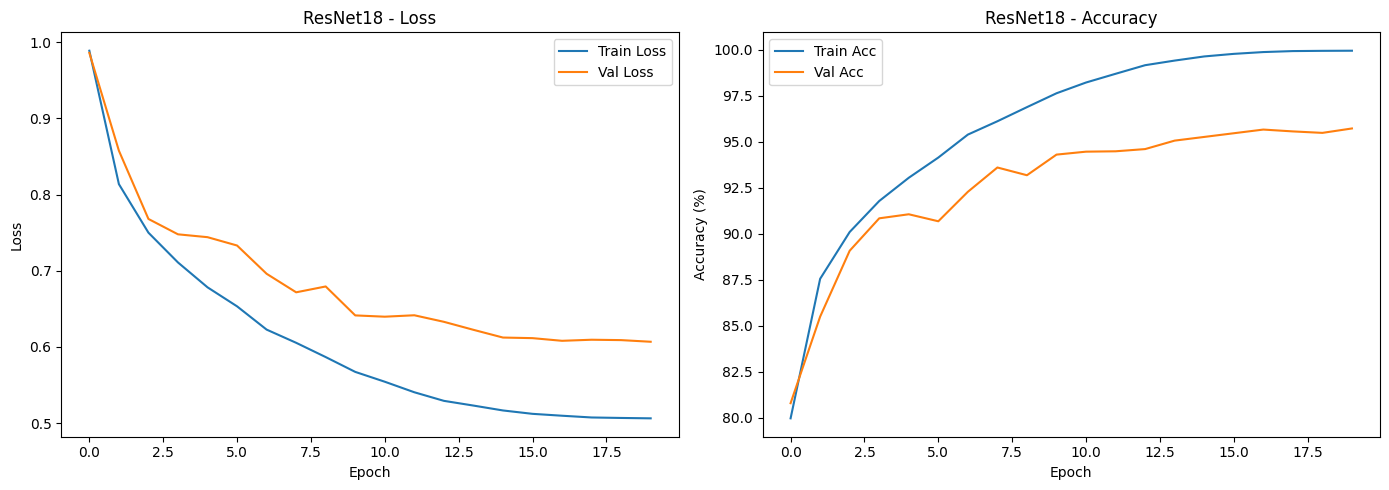

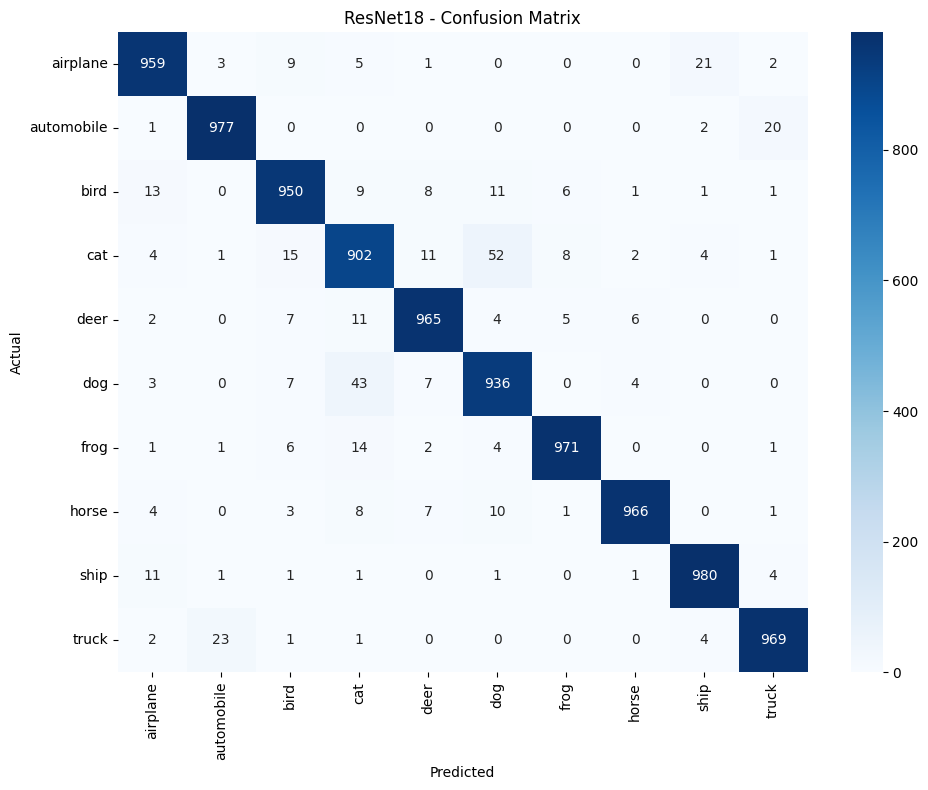

In [ ]:
plot_history(resnet18_history,     'ResNet18')

plot_confusion_matrix(resnet18_cm,     'ResNet18')

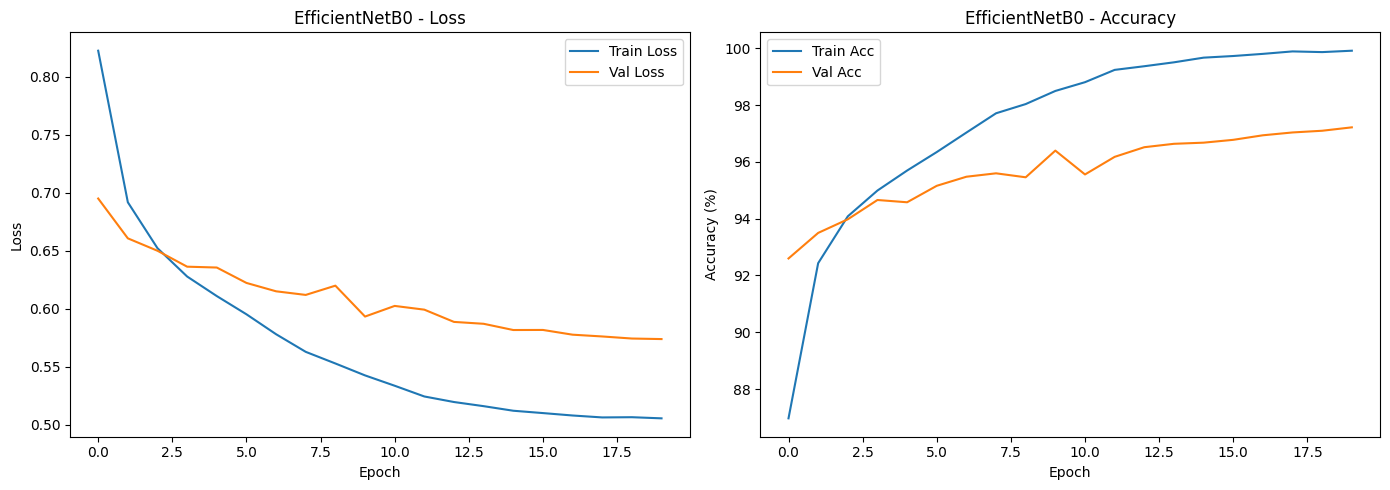

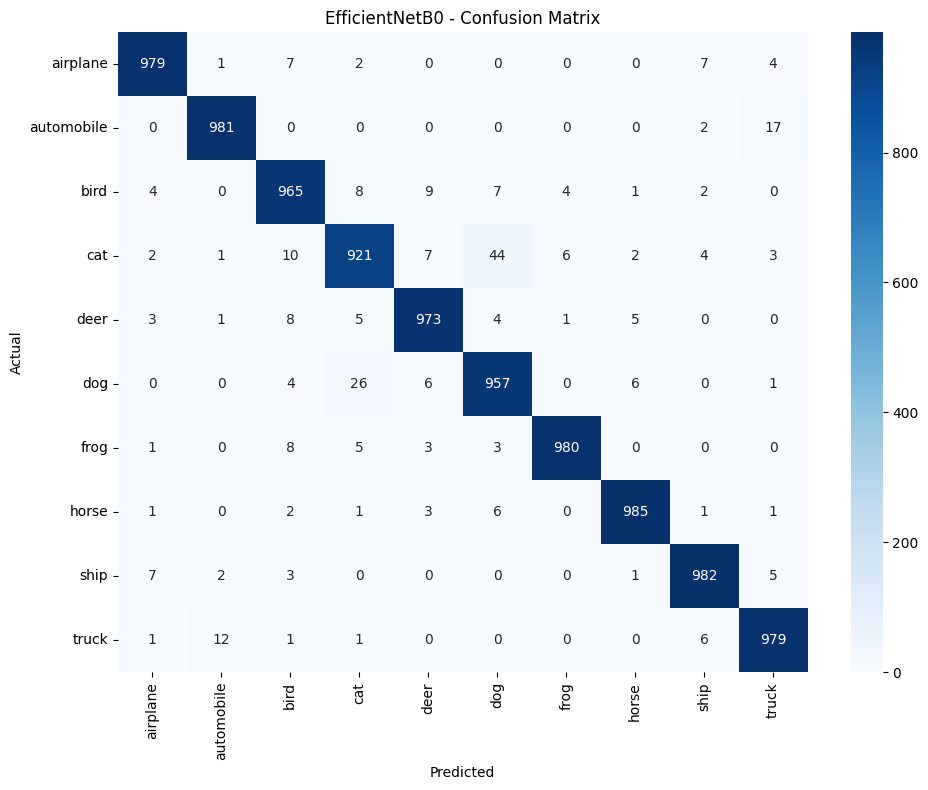

In [ ]:
plot_history(efficientnet_history, 'EfficientNetB0')

plot_confusion_matrix(efficientnet_cm, 'EfficientNetB0')

## 8. Load Saved Models (Skip Training Next Time)

Already trained? Just run Section 1 (imports) and Section 4 (model definitions), then run this cell.
The .pth files are saved in the cifar10_models folder next to this notebook.

In [ ]:
resnet18_model = build_resnet18().to(device)
resnet18_model.load_state_dict(torch.load(f'{SAVE_DIR}/resnet18_cifar10.pth', map_location=device))
resnet18_model.eval()

efficientnet_model = build_efficientnet_b0().to(device)
efficientnet_model.load_state_dict(torch.load(f'{SAVE_DIR}/efficientnetb0_cifar10.pth', map_location=device))
efficientnet_model.eval()

print('All models loaded')

All models loaded


## 9. Test on a Single Image

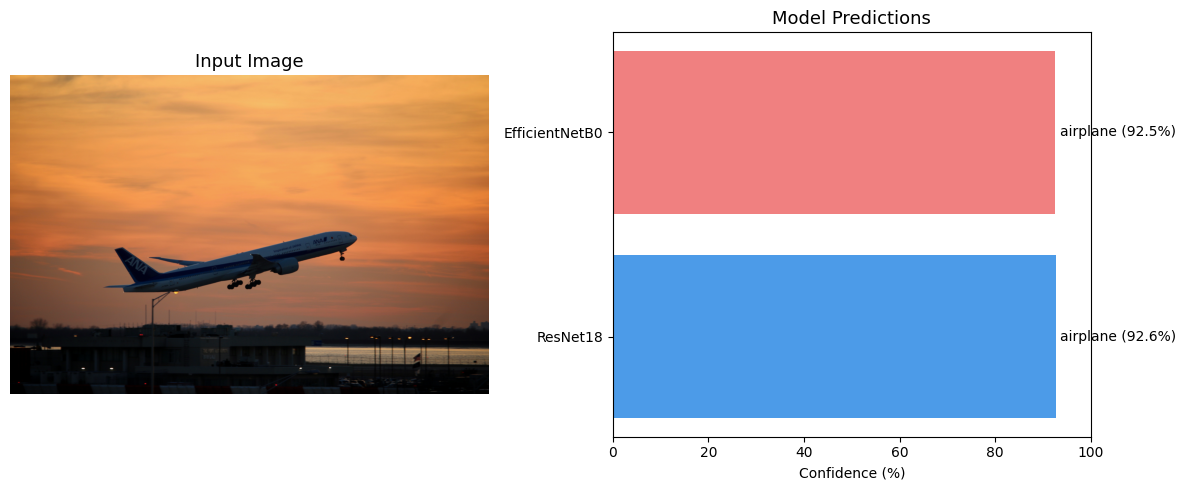

ResNet18       => airplane (92.59%)
EfficientNetB0 => airplane (92.55%)


In [ ]:
IMAGE_PATH = 'ANA_777-300_Taking_off_from_JFK.jpg'

img = Image.open(IMAGE_PATH).convert('RGB')

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

img_tensor = infer_transform(img).unsqueeze(0).to(device)

def predict(model, img_tensor):
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        pred    = probs.argmax().item()
    return CLASSES[pred], probs[pred].item() * 100

r_class, r_conf = predict(resnet18_model,     img_tensor)
e_class, e_conf = predict(efficientnet_model, img_tensor)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Input Image', fontsize=13)

model_names = ['ResNet18', 'EfficientNetB0']
predictions = [f'{r_class} ({r_conf:.1f}%)', f'{e_class} ({e_conf:.1f}%)']
colors      = ['#4C9BE8', '#F08080']

bars = axes[1].barh(model_names, [r_conf, e_conf], color=colors)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('Model Predictions', fontsize=13)

for bar, pred in zip(bars, predictions):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                 pred, va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'ResNet18       => {r_class} ({r_conf:.2f}%)')
print(f'EfficientNetB0 => {e_class} ({e_conf:.2f}%)')